<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/NN_baseline_model_ipynbipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Provide path
data=pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [14]:
data_baselinemodel=data.copy()

In [15]:
data_baselinemodel.head()

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,TotalCharges_numeric,TotalCharges_log,gender_Male,SeniorCitizen_1,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0.013889,0.115423,29.85,0,29.85,0.072892,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,0.472222,0.385075,1889.5,0,1889.50,0.749358,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0.027778,0.354229,108.15,1,108.15,0.280590,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,0.625000,0.239303,1840.75,0,1840.75,0.745063,1,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,0.027778,0.521891,151.65,1,151.65,0.335724,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [28]:
# make sure the column names exist
cols_to_drop = ['customerID','Churn', 'TotalCharges', 'TotalCharges_numeric']

# create X by dropping columns
X = data_baselinemodel.drop(columns=cols_to_drop, axis=1)

# create y
y = data_baselinemodel['Churn']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% test set
    stratify=y,            # preserve churn ratio
    random_state=42        # reproducible split
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 30) (5634,)
Test shape:  (1409, 30) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 5634 non-null   float64
 1   MonthlyCharges                         5634 non-null   float64
 2   TotalCharges_log                       5634 non-null   float64
 3   gender_Male                            5634 non-null   int64  
 4   SeniorCitizen_1                        5634 non-null   int64  
 5   Partner_Yes                            5634 non-null   int64  
 6   Dependents_Yes                         5634 non-null   int64  
 7   PhoneService_Yes                       5634 non-null   int64  
 8   MultipleLines_No phone service         5634 non-null   int64  
 9   MultipleLines_Yes                      5634 non-null   int64  
 10  InternetService_Fiber optic            5634 non-null   int64  
 11  Intern

In [31]:
# First 5 rows of training features
print("X_train sample:")
print(X_train.head())

# First 5 rows of training target
print("\ny_train sample:")
print(y_train.head())

# First 5 rows of test features
print("\nX_test sample:")
print(X_test.head())

# First 5 rows of test target
print("\ny_test sample:")
print(y_test.head())

X_train sample:
        tenure  MonthlyCharges  TotalCharges_log  gender_Male  \
3738  0.486111        0.307960          0.732155            1   
3151  0.208333        0.565672          0.668016            1   
4860  0.180556        0.221891          0.558327            1   
3867  0.361111        0.549751          0.750760            0   
3810  0.013889        0.261692          0.136943            1   

      SeniorCitizen_1  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3738                0            0               0                 0   
3151                0            1               1                 1   
4860                0            1               1                 0   
3867                0            1               0                 1   
3810                0            1               1                 1   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
3738                               1                  0  ...   
3151                            

In [32]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
# Baseline Neural Network
baseline_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden layer 1
    Dense(16, activation='relu'),                                     # Hidden layer 2
    Dense(1, activation='sigmoid')                                    # Output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
from tensorflow.keras.metrics import Precision, Recall, AUC

baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC(name='auc')]
)

In [35]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=20,             # baseline
    batch_size=32,         # default
    validation_split=0.2,  # 20% of train used as validation
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6800 - auc: 0.6813 - loss: 0.5715 - precision_1: 0.3910 - recall_1: 0.2990 - val_accuracy: 0.7764 - val_auc: 0.8050 - val_loss: 0.4576 - val_precision_1: 0.5931 - val_recall_1: 0.4644
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8038 - auc: 0.8433 - loss: 0.4232 - precision_1: 0.6630 - recall_1: 0.5376 - val_accuracy: 0.7808 - val_auc: 0.8191 - val_loss: 0.4439 - val_precision_1: 0.5930 - val_recall_1: 0.5186
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - auc: 0.8449 - loss: 0.4209 - precision_1: 0.6689 - recall_1: 0.5401 - val_accuracy: 0.7835 - val_auc: 0.8227 - val_loss: 0.4408 - val_precision_1: 0.5927 - val_recall_1: 0.5525
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - auc: 0.8487 - loss: 0.4154 - precision_1: 0.6462 - recall_1: 0.5299 - val_accuracy: 0.7808 - val_auc: 0.8251 - val_loss: 0.4377 - val_precision_1: 0.5902 - val_recall_1: 0.5322


In [37]:
test_metrics = baseline_model.evaluate(X_test, y_test, verbose=1)
print("Test loss and metrics:", test_metrics)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7875 - auc: 0.8356 - loss: 0.4310 - precision_1: 0.6301 - recall_1: 0.5133
Test loss and metrics: [0.4211546778678894, 0.7941802740097046, 0.6409395933151245, 0.5106951594352722, 0.841067910194397]


In [38]:
from sklearn.metrics import f1_score
import numpy as np

# Get predicted probabilities
y_pred_prob = baseline_model.predict(X_test)

# Convert probabilities to 0/1 (using 0.5 threshold)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute F1-score
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
F1-score: 0.5684523809523809


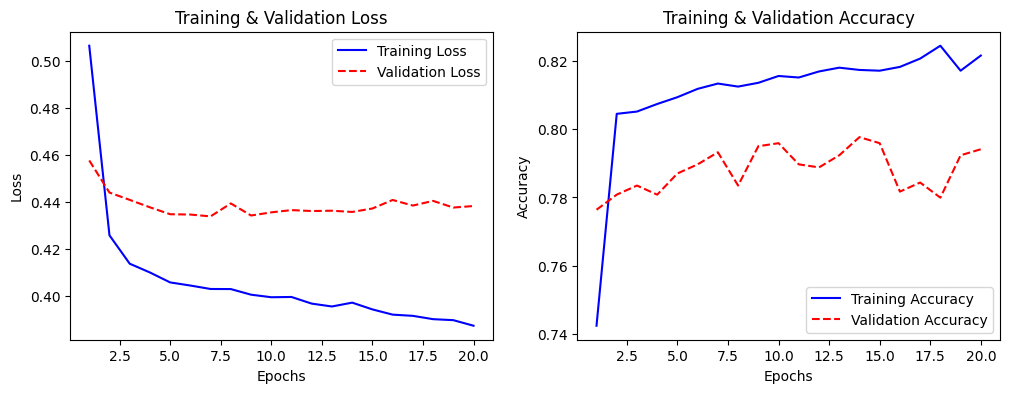

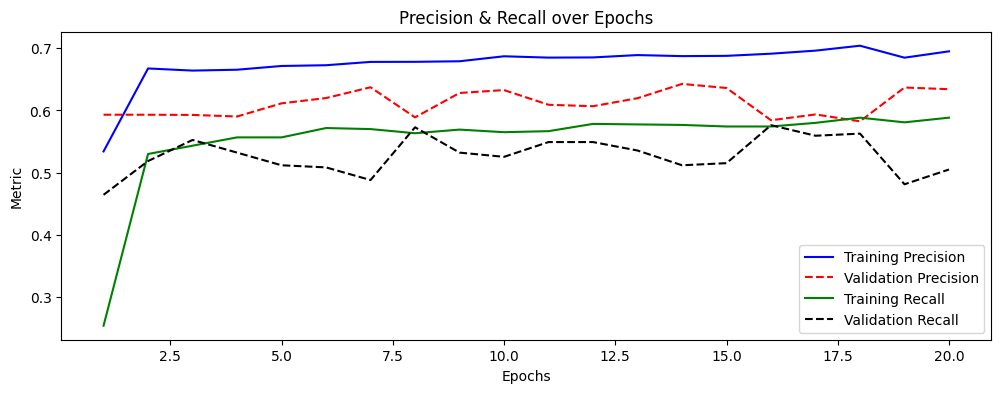

In [39]:
import matplotlib.pyplot as plt

# Extract metrics from history
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
precision = history.history['precision_1']
val_precision = history.history['val_precision_1']
recall = history.history['recall_1']
val_recall = history.history['val_recall_1']

epochs = range(1, len(loss)+1)

# Plot Loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r--', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r--', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Optional: Plot Precision and Recall
plt.figure(figsize=(12,4))
plt.plot(epochs, precision, 'b-', label='Training Precision')
plt.plot(epochs, val_precision, 'r--', label='Validation Precision')
plt.plot(epochs, recall, 'g-', label='Training Recall')
plt.plot(epochs, val_recall, 'k--', label='Validation Recall')
plt.title('Precision & Recall over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Metric')
plt.legend()
plt.show()

**Baseline Neural Network Model – Summary**

Model Architecture

    Input Layer: Size = number of features (X_train.shape[1])

    Hidden Layers:

      Dense(32, activation='relu')

      Dense(16, activation='relu')

      Output Layer: Dense(1, activation='sigmoid')

Training Configuration (Hyperparameters)

    Optimizer: adam (default learning rate = 0.001)

    Loss function: binary_crossentropy

    Metrics: accuracy, Precision, Recall, AUC

    Epochs: 20

    Batch size: 32

    Validation split: 20% of training data

Learned Parameters

    Weights and biases for all layers (learned during training)

Performance on Test Set

    Accuracy: 79.4%

    Precision: 64.1%

    Recall: 51.1%

    F1-score: 0.568

    AUC: 0.841

Observations


*   Accuracy is reasonably high, but recall is low.
*   Class imbalance (1:3) is likely causing the model to favor the majority class.
*   F1-score indicates the balance between precision and recall can be improved.

Next Steps

*   Address class imbalance using class weights or resampling.
*   Adjust the classification threshold to improve recall and F1-score.
*   Optionally tune hyperparameters (epochs, batch size, learning rate, dropout) after addressing imbalance.










